<a href="https://colab.research.google.com/github/kk7188048/ML-From-Scratch/blob/master/LLM_Playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip uninstall -y numpy datasets torch
!pip install datasets tokenizers torch streamlit -q --ignore-installed blinker

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
ERROR: Operation cancelled by user
^C


KeyboardInterrupt: 

In [4]:
# 1. Install Python packages (Relying on Colab's pre-installed PyTorch)
!pip install -q fastapi uvicorn[standard] motor pymongo streamlit transformers accelerate bitsandbytes

# 2. Install MongoDB Community Edition for Linux
!apt-get install -y gnupg curl
!curl -fsSL https://pgp.mongodb.com/server-7.0.asc | sudo gpg -o /usr/share/keyrings/mongodb-server-7.0.gpg --dearmor
!echo "deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse" | sudo tee /etc/apt/sources.list.d/mongodb-org-7.0.list
!apt-get update -q
!apt-get install -y mongodb-org

# 3. Create the data directory MongoDB needs
!mkdir -p /data/db

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 35.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (7.81.0-1ubuntu1.21).
gnupg is already the newest version (2.2.27-3ubuntu2.5).
gnupg set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
deb [ arch=amd64,arm64 signed-by=/usr/share/keyrings/mongodb-server-7.0.gpg ] https://repo.mongodb.org/apt/ubuntu jammy/mongodb-org/7.0 multiverse
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64

In [22]:
!pip uninstall -y numpy datasets
!pip install "numpy<2.0.0" -q

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires datasets, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
pymc 5.28.0 requires cachetools<7,>=4.2.1, but you have cachetools 7.0.2 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version 

In [7]:
from datasets import load_dataset
dataset = load_dataset(
    "HuggingFaceFW/fineweb",
    name="sample-10BT",
    split="train",
    streaming=True
)
raw_docs = []
for i, example in enumerate(dataset):
    if i >= 500:
        break
    raw_docs.append(example['text'])
    if i % 100 == 0:
        print(f"Processed {i} documents")
print(f"Collected: {len(raw_docs)} documents")
print(f"Raw document \n{raw_docs}")
print(f"Sample:\n{raw_docs[0]}")
print(f"Sample:\n{raw_docs[0][:300]}")

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

Processed 0 documents
Processed 100 documents
Processed 200 documents
Processed 300 documents
Processed 400 documents
Collected: 500 documents
Raw document 
['|Viewing Single Post From: Spoilers for the Week of February 11th|\n|Lil||Feb 1 2013, 09:58 AM|\nDon\'t care about Chloe/Taniel/Jen-Jen. Don\'t care about Sami, really, but hoping that we get some good "SAMANTHA GENE!!" Marlena Death-Stares out of it. And "newfound" feelings. Please. If only.\nSTEFANO!! STEFANO, STEFANO, STEFANO!!!! :cheer:\n|Spoilers for the Week of February 11th · DAYS: News, Spoilers & Discussion|', '*sigh* Fundamentalist community, let me pass on some advice to you I learned from the atheistic community:\nIf you have set yourself on fire, do not run.\nOkay? Okay?? Please?\nLook, D, you had two months to say to Harvard in private emails, "Im sorry, I shouldnt have been using that animation in my paid presentations. I wont use it again. I really do like \'Inner Life\', though, and would love to use it in classr

In [8]:
import re

def clean_text(text):
    # 1. Remove HTML tags if any slipped through
    text = re.sub(r'<[^>]+>', '', text)

    # 2. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Remove lines that are too short (nav menus, buttons, etc.)
    lines = text.split('. ')
    lines = [l for l in lines if len(l.split()) > 5]
    text = '. '.join(lines)

    return text

def is_quality_doc(text):
    # Filter out garbage documents
    if len(text.split()) < 100:        # too short
        return False
    if len(text) > 100_000:            # absurdly long
        return False
    if text.count('http') > 10:        # link-spam
        return False
    return True

# Apply to all 500 docs
cleaned_docs = []
rejected = 0

for doc in raw_docs:
    cleaned = clean_text(doc)
    if is_quality_doc(cleaned):
        cleaned_docs.append(cleaned)
    else:
        rejected += 1

print(f"✅ Kept: {len(cleaned_docs)} documents")
print(f"🗑️  Rejected: {rejected} documents")
print(f"\n📄 Before cleaning ({len(raw_docs[0])} chars):\n{raw_docs[0][:300]}")
print(f"\n✨ After cleaning ({len(cleaned_docs[0])} chars):\n{cleaned_docs[0][:300]}")

✅ Kept: 424 documents
🗑️  Rejected: 76 documents

📄 Before cleaning (414 chars):
|Viewing Single Post From: Spoilers for the Week of February 11th|
|Lil||Feb 1 2013, 09:58 AM|
Don't care about Chloe/Taniel/Jen-Jen. Don't care about Sami, really, but hoping that we get some good "SAMANTHA GENE!!" Marlena Death-Stares out of it. And "newfound" feelings. Please. If only.
STEFANO!! 

✨ After cleaning (2952 chars):
*sigh* Fundamentalist community, let me pass on some advice to you I learned from the atheistic community: If you have set yourself on fire, do not run. Okay? Okay?? Please? Look, D, you had two months to say to Harvard in private emails, "Im sorry, I shouldnt have been using that animation in my pa


In [9]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Initialize BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Train on our cleaned docs
trainer = BpeTrainer(
    vocab_size=8000,          # Small vocab for our tiny model
    min_frequency=2,          # Token must appear at least twice
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"]
)

tokenizer.train_from_iterator(cleaned_docs, trainer=trainer)

# Save tokenizer
tokenizer.save("tokenizer.json")
print(f"Tokenizer trained! Vocab size: {tokenizer.get_vocab_size()}")

# Quick test
sample = cleaned_docs[0][:200]
encoded = tokenizer.encode(sample)
print(f"\nSample text:\n{sample}")
print(f"\nToken IDs (first 20): {encoded.ids[:20]}")
print(f"Tokens (first 20): {encoded.tokens[:20]}")
print(f"Text length: {len(sample)} chars → {len(encoded.ids)} tokens")

Tokenizer trained! Vocab size: 8000

Sample text:
*sigh* Fundamentalist community, let me pass on some advice to you I learned from the atheistic community: If you have set yourself on fire, do not run. Okay? Okay?? Please? Look, D, you had two month

Token IDs (first 20): [13, 86, 316, 13, 5430, 1860, 6121, 353, 1639, 15, 690, 382, 946, 222, 455, 3800, 232, 314, 44, 5071]
Tokens (first 20): ['*', 's', 'igh', '*', 'Fun', 'dam', 'ental', 'ist', 'community', ',', 'let', 'me', 'pass', 'on', 'some', 'advice', 'to', 'you', 'I', 'learned']
Text length: 200 chars → 52 tokens


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── 1. Tokenize all documents ──────────────────────────────────────
all_token_ids = []
for doc in cleaned_docs:
    enc = tokenizer.encode(doc)
    all_token_ids.extend(enc.ids)

print(f"📊 Total tokens: {len(all_token_ids):,}")

# ── 2. Dataset: sliding window chunks ─────────────────────────────
class TextDataset(Dataset):
    def __init__(self, token_ids, seq_len=128):
        self.seq_len = seq_len
        self.data = torch.tensor(token_ids, dtype=torch.long)

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]  # shifted by 1
        return x, y

SEQ_LEN = 128
dataset = TextDataset(all_token_ids, seq_len=SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"📦 Dataset chunks: {len(dataset):,}")
print(f"🔁 Batches per epoch: {len(dataloader):,}")

# ── 3. Tiny GPT Model ──────────────────────────────────────────────
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4, seq_len=128):
        super().__init__()
        self.token_emb  = nn.Embedding(vocab_size, d_model)
        self.pos_emb    = nn.Embedding(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=512, dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln   = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)  # (1, T)
        x = self.token_emb(x) + self.pos_emb(positions)

        # Causal mask — each token only attends to past tokens
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        x = self.transformer(x, mask=mask, is_causal=True)

        x = self.ln(x)
        return self.head(x)  # (B, T, vocab_size)

VOCAB_SIZE = tokenizer.get_vocab_size()
model = TinyGPT(vocab_size=VOCAB_SIZE)

total_params = sum(p.numel() for p in model.parameters())
print(f"\n🧠 Model parameters: {total_params:,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"⚡ Device: {device}")

📊 Total tokens: 360,018
📦 Dataset chunks: 359,890
🔁 Batches per epoch: 5,624

🧠 Model parameters: 2,865,728
⚡ Device: cuda


  Epoch 1 | Batch 0/5624 | Loss: 9.1470
  Epoch 1 | Batch 50/5624 | Loss: 7.5645
  Epoch 1 | Batch 100/5624 | Loss: 7.2593
  Epoch 1 | Batch 150/5624 | Loss: 7.1862
  Epoch 1 | Batch 200/5624 | Loss: 7.0398
  Epoch 1 | Batch 250/5624 | Loss: 6.9864
  Epoch 1 | Batch 300/5624 | Loss: 6.9536
  Epoch 1 | Batch 350/5624 | Loss: 6.8168
  Epoch 1 | Batch 400/5624 | Loss: 6.7393
  Epoch 1 | Batch 450/5624 | Loss: 6.6806
  Epoch 1 | Batch 500/5624 | Loss: 6.6858
  Epoch 1 | Batch 550/5624 | Loss: 6.5650
  Epoch 1 | Batch 600/5624 | Loss: 6.5900
  Epoch 1 | Batch 650/5624 | Loss: 6.4901
  Epoch 1 | Batch 700/5624 | Loss: 6.3989
  Epoch 1 | Batch 750/5624 | Loss: 6.4005
  Epoch 1 | Batch 800/5624 | Loss: 6.2788
  Epoch 1 | Batch 850/5624 | Loss: 6.3439
  Epoch 1 | Batch 900/5624 | Loss: 6.2081
  Epoch 1 | Batch 950/5624 | Loss: 6.2774
  Epoch 1 | Batch 1000/5624 | Loss: 6.0763
  Epoch 1 | Batch 1050/5624 | Loss: 6.0955
  Epoch 1 | Batch 1100/5624 | Loss: 6.0368
  Epoch 1 | Batch 1150/5624 | Loss

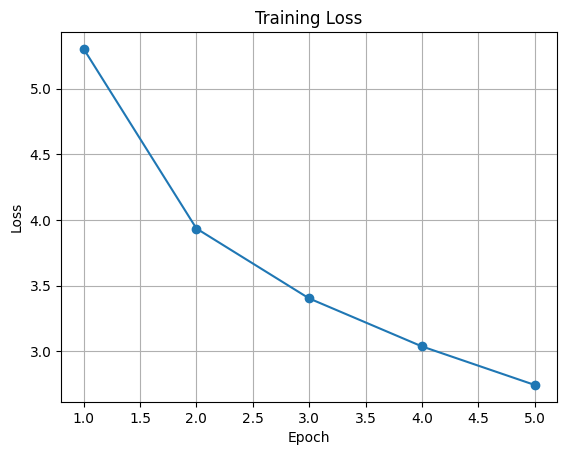

In [11]:
import time

# ── Optimizer & Loss ───────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# ── Training ───────────────────────────────────────────────────────
EPOCHS = 5
losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    start = time.time()

    for batch_idx, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device)

        logits = model(x)                          # (B, T, vocab_size)
        loss = criterion(
            logits.view(-1, VOCAB_SIZE),           # (B*T, vocab_size)
            y.view(-1)                             # (B*T,)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx}/{len(dataloader)} | Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    elapsed = time.time() - start
    print(f"\n✅ Epoch {epoch+1}/{EPOCHS} | Avg Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s\n")

# ── Save model ─────────────────────────────────────────────────────
torch.save(model.state_dict(), "tinygpt.pt")
print("💾 Model saved to tinygpt.pt")

# ── Loss curve ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.plot(range(1, EPOCHS+1), losses, marker='o')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss")
plt.grid(True); plt.show()

In [12]:
def generate(prompt, max_new_tokens=100, strategy="greedy", temperature=1.0, top_k=50, top_p=0.9):
    model.eval()
    input_ids = tokenizer.encode(prompt).ids
    x = torch.tensor([input_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(x)
            next_logits = logits[0, -1, :] / temperature  # last token's logits

            if strategy == "greedy":
                next_id = torch.argmax(next_logits).item()

            elif strategy == "top_k":
                top_k_vals, top_k_idx = torch.topk(next_logits, top_k)
                probs = torch.softmax(top_k_vals, dim=-1)
                chosen = torch.multinomial(probs, 1).item()
                next_id = top_k_idx[chosen].item()

            elif strategy == "top_p":
                sorted_logits, sorted_idx = torch.sort(next_logits, descending=True)
                probs = torch.softmax(sorted_logits, dim=-1)
                cumulative = torch.cumsum(probs, dim=0)
                # Remove tokens once cumulative prob exceeds top_p
                cutoff = (cumulative - probs) > top_p
                sorted_logits[cutoff] = float('-inf')
                filtered_probs = torch.softmax(sorted_logits, dim=-1)
                chosen = torch.multinomial(filtered_probs, 1).item()
                next_id = sorted_idx[chosen].item()

            x = torch.cat([x, torch.tensor([[next_id]]).to(device)], dim=1)

            # Stop at EOS
            if next_id == tokenizer.token_to_id("[EOS]"):
                break

    generated_ids = x[0].tolist()[len(input_ids):]
    return tokenizer.decode(generated_ids)


# ── Compare all strategies ─────────────────────────────────────────
prompt = "The future of technology"

print(f"📝 Prompt: '{prompt}'\n")
print("=" * 60)

print("🎯 GREEDY:")
print(generate(prompt, strategy="greedy"))
print()

print("🎲 TOP-K (k=50, temp=0.8):")
print(generate(prompt, strategy="top_k", temperature=0.8, top_k=50))
print()

print("🌊 TOP-P (p=0.9, temp=0.9):")
print(generate(prompt, strategy="top_p", temperature=0.9, top_p=0.9))
print()

📝 Prompt: 'The future of technology'

🎯 GREEDY:
. The institution responsible for the corpor ations of the laws and the sac red cards issued the international community . The prepar ations of the Council of the human rights , particularly difficult ies , particularly between the U . S . and the core of the core of the core national accounts , the international examples of the data and demand for the international development of research and developing infrastructure ( particularly given to cells , predict the development of the development of the development of the development of the development of the development of the development of

🎲 TOP-K (k=50, temp=0.8):
but it was never something akin . The ye h ä us , is to do 53 R is a con spir acy to make . I ' m an ab bot min ous ence . 02 - 25 , 06 - 02 - 26 : 01 PM I ' m not sure I ' ve no ve been here at a lot of mid night . It ' s got ! I ' m now , but I certainly wasn ' t written for the br ut ious ! And it ! You have a great ! Once !

In [19]:
# Removed problematic numpy installation that caused version conflicts.

In [23]:
%%writefile app.py

import streamlit as st
import torch
import torch.nn as nn
from tokenizers import Tokenizer

# ── Model definition (must match training) ────────────────────────
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4, seq_len=128):
        super().__init__()
        self.token_emb  = nn.Embedding(vocab_size, d_model)
        self.pos_emb    = nn.Embedding(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=512, dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln   = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(positions)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        x = self.transformer(x, mask=mask, is_causal=True)
        x = self.ln(x)
        return self.head(x)

# ── Load model & tokenizer ─────────────────────────────────────────
@st.cache_resource
def load_model():
    tokenizer = Tokenizer.from_file("tokenizer.json")
    vocab_size = tokenizer.get_vocab_size()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TinyGPT(vocab_size=vocab_size).to(device)
    model.load_state_dict(torch.load("tinygpt.pt", map_location=device))
    model.eval()
    return model, tokenizer, device

# ── Generation function ────────────────────────────────────────────
def generate(model, tokenizer, device, prompt, max_new_tokens, strategy, temperature, top_k, top_p):
    input_ids = tokenizer.encode(prompt).ids
    x = torch.tensor([input_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(x)
            next_logits = logits[0, -1, :] / temperature

            if strategy == "Greedy":
                next_id = torch.argmax(next_logits).item()

            elif strategy == "Top-K":
                top_k_vals, top_k_idx = torch.topk(next_logits, top_k)
                probs = torch.softmax(top_k_vals, dim=-1)
                chosen = torch.multinomial(probs, 1).item()
                next_id = top_k_idx[chosen].item()

            elif strategy == "Top-P":
                sorted_logits, sorted_idx = torch.sort(next_logits, descending=True)
                probs = torch.softmax(sorted_logits, dim=-1)
                cumulative = torch.cumsum(probs, dim=0)
                cutoff = (cumulative - probs) > top_p
                sorted_logits[cutoff] = float('-inf')
                filtered_probs = torch.softmax(sorted_logits, dim=-1)
                chosen = torch.multinomial(filtered_probs, 1).item()
                next_id = sorted_idx[chosen].item()

            x = torch.cat([x, torch.tensor([[next_id]]).to(device)], dim=1)
            if next_id == tokenizer.token_to_id("[EOS]"):
                break

    generated_ids = x[0].tolist()[len(input_ids):]
    return tokenizer.decode(generated_ids)

# ── UI ─────────────────────────────────────────────────────────────
st.set_page_config(page_title="TinyGPT Playground", page_icon="🧠")
st.title("🧠 TinyGPT Playground")
st.caption("Trained on 424 FineWeb documents · ~5M parameters")

model, tokenizer, device = load_model()

col1, col2 = st.columns([2, 1])

with col1:
    prompt = st.text_area("Prompt", value="The future of technology", height=100)

with col2:
    strategy = st.selectbox("Strategy", ["Greedy", "Top-K", "Top-P"])
    max_tokens = st.slider("Max new tokens", 20, 200, 100)
    temperature = st.slider("Temperature", 0.1, 2.0, 0.9, step=0.1)
    if strategy == "Top-K":
        top_k = st.slider("Top-K", 5, 100, 50)
    else:
        top_k = 50
    if strategy == "Top-P":
        top_p = st.slider("Top-P", 0.1, 1.0, 0.9, step=0.05)
    else:
        top_p = 0.9

if st.button("Generate ✨", type="primary"):
    with st.spinner("Generating..."):
        output = generate(model, tokenizer, device, prompt, max_tokens, strategy, temperature, top_k, top_p)
    st.subheader("Output")
    st.write(output)

# ── Side by side comparison ────────────────────────────────────────
st.divider()
st.subheader("⚖️ Strategy Comparison")
if st.button("Compare all strategies"):
    with st.spinner("Running all three..."):
        g = generate(model, tokenizer, device, prompt, max_tokens, "Greedy",  1.0,  50, 0.9)
        k = generate(model, tokenizer, device, prompt, max_tokens, "Top-K",   0.8,  50, 0.9)
        p = generate(model, tokenizer, device, prompt, max_tokens, "Top-P",   0.9,  50, 0.9)

    c1, c2, c3 = st.columns(3)
    with c1:
        st.markdown("**🎯 Greedy**")
        st.write(g)
    with c2:
        st.markdown("**🎲 Top-K**")
        st.write(k)
    with c3:
        st.markdown("**🌊 Top-P**")
        st.write(p)

Overwriting app.py


In [28]:
# Install pyngrok for tunneling out of Colab
!pip install pyngrok -q

from pyngrok import ngrok
import subprocess, time

# IMPORTANT: Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok authtoken
# You can get one for free from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('2n6kDdcomKkYMtU7VGoG5Jo3dxL_7QDuLhHES8QVngyMKWHFx')

# Start streamlit in background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"])
time.sleep(3)

# Create public URL
public_url = ngrok.connect(8501)
print(f"🚀 App live at: {public_url}")

🚀 App live at: NgrokTunnel: "https://8ca6-34-145-30-91.ngrok-free.app" -> "http://localhost:8501"
